In [1]:
# Import essential models and functions from sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()

In [2]:
d1=pd.read_csv('clean_data.csv')
d=pd.read_csv('owid-energy-data.csv')

Algeria=pd.DataFrame(d1[d1["country"]=="Algeria"])

alg_inputs=pd.DataFrame(Algeria[["population","electricity_generation","primary_energy_consumption","fossil_share_energy","energy_per_capita"]])
alg_output=pd.DataFrame(Algeria[["gdp"]])

# Isolate Algeria from the original full dataset
algeria_raw = d[d["country"] == "Algeria"]

# Candidate pool: broaden beyond your original 5
expanded_candidates = [
    "population", "electricity_generation", "primary_energy_consumption", 
    "fossil_share_energy", "energy_per_capita",
    "renewables_share_energy", "coal_share_energy", "oil_share_energy", "gas_share_energy",
    "electricity_demand", "greenhouse_gas_emissions", "carbon_intensity_elec",
    "low_carbon_share_energy", "renewables_share_elec"
]

# Check non-null coverage for Algeria specifically, across your relevant years
algeria_window = algeria_raw[(algeria_raw["year"] >= 1985) & (algeria_raw["year"] <= 2015)]
coverage = algeria_window[expanded_candidates].notna().sum().sort_values(ascending=False)
print(coverage)

candidate_features = [
    "population", "electricity_generation", "primary_energy_consumption", 
    "fossil_share_energy", "energy_per_capita",
    "renewables_share_energy", "coal_share_energy", "oil_share_energy", "gas_share_energy",
    "low_carbon_share_energy", "renewables_share_elec"
]

pd.set_option('display.max_rows', None)

correlations = algeria_window[candidate_features + ["gdp"]].corr(numeric_only=True)["gdp"]
correlations = correlations.drop("gdp")
correlations = correlations.sort_values(ascending=False)
print(correlations)

population                    31
electricity_generation        31
primary_energy_consumption    31
fossil_share_energy           31
energy_per_capita             31
renewables_share_energy       31
coal_share_energy             31
oil_share_energy              31
gas_share_energy              31
low_carbon_share_energy       31
renewables_share_elec         31
electricity_demand            16
greenhouse_gas_emissions      16
carbon_intensity_elec         16
dtype: int64
electricity_generation        0.977752
population                    0.950853
primary_energy_consumption    0.944425
oil_share_energy              0.786734
energy_per_capita             0.592352
fossil_share_energy           0.292323
renewables_share_energy      -0.292323
low_carbon_share_energy      -0.292323
renewables_share_elec        -0.409719
gas_share_energy             -0.523020
coal_share_energy            -0.807334
Name: gdp, dtype: float64


(25, 2) (6, 2)
Intercept of Regression 	: b =  -519294569210.37067
Coefficients of Regression 	: a =  [1.15266883e+04 1.19754815e+09]

                   Predictors  Coefficients
0                  population  1.152669e+04
1  primary_energy_consumption  1.197548e+09



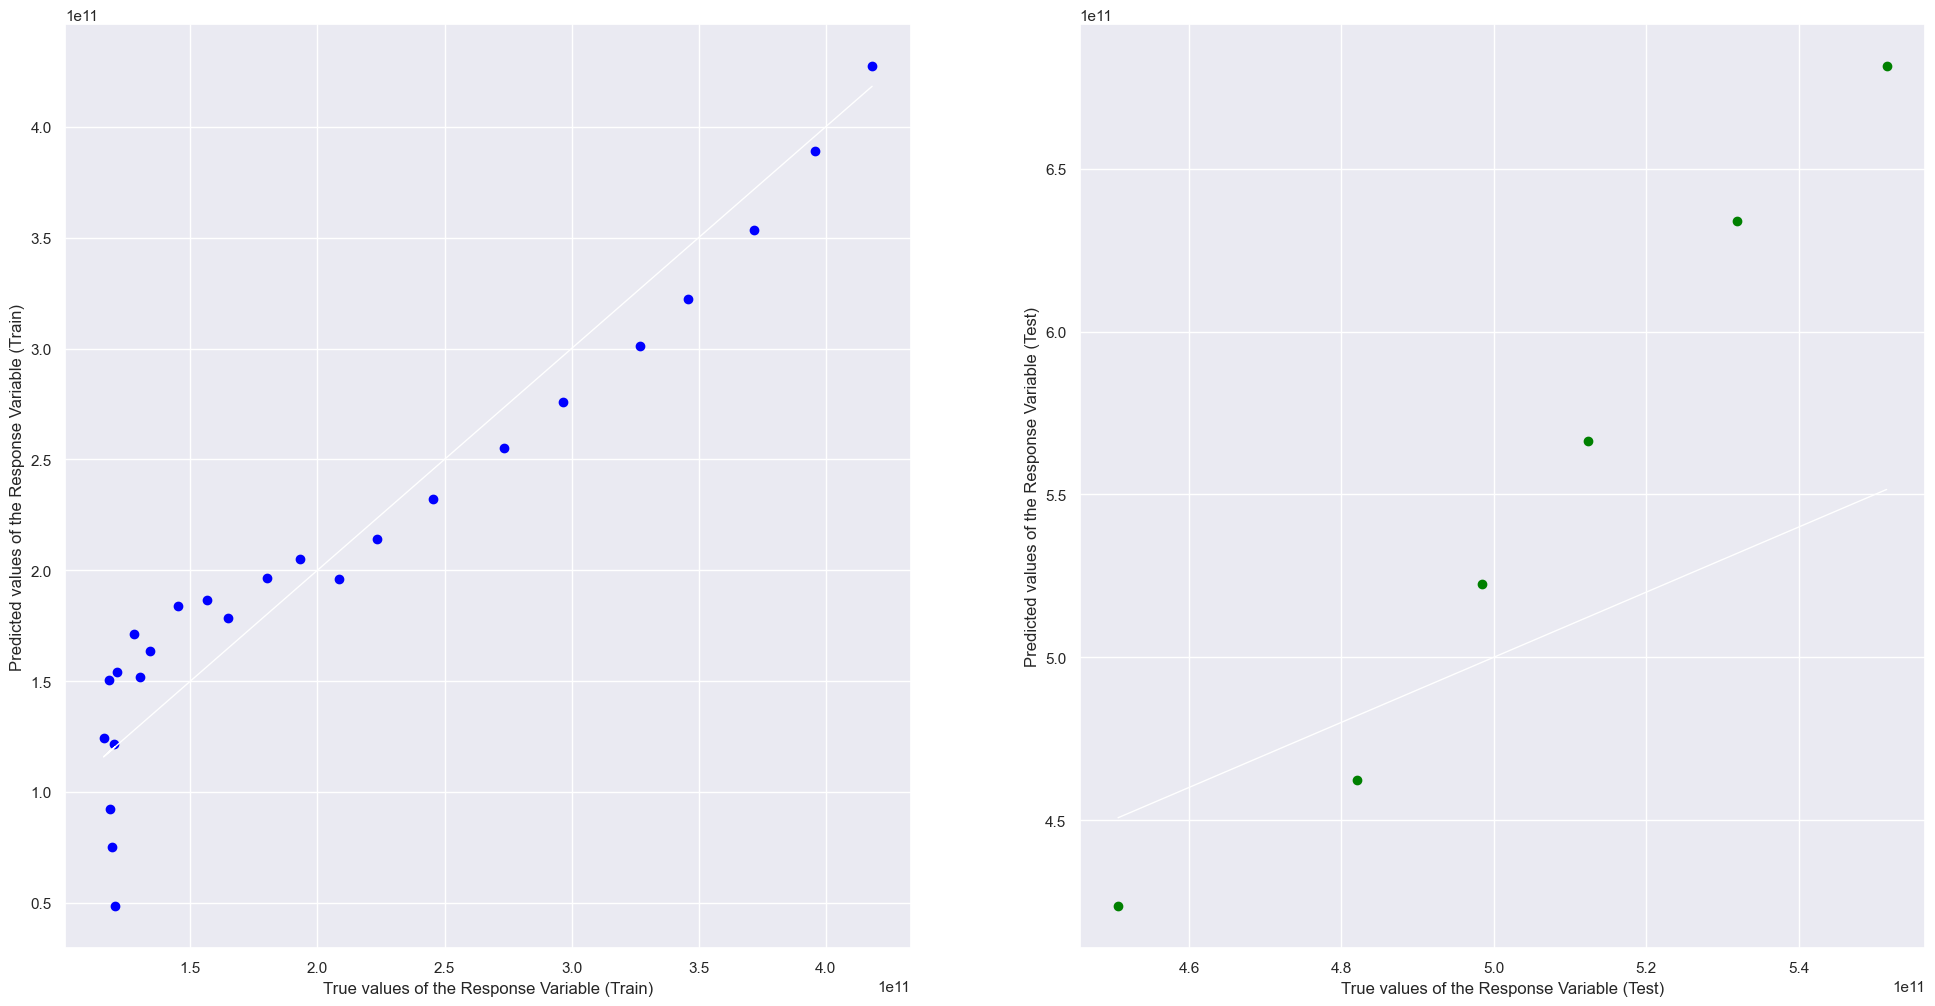

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9192618314684029
Mean Squared Error (MSE) 	: 7.622420633741264e+20

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: -3.9498670151867064
Mean Squared Error (MSE) 	: 5.326444695198904e+21



In [3]:
# 2 Predictors


Algeria = pd.DataFrame(d1[d1["country"] == "Algeria"])

# Just the column names now — plain lists, not DataFrames
feature_cols = ["population","primary_energy_consumption"]
target_col = "gdp"

train_df = Algeria[Algeria["year"] < 2010]
test_df  = Algeria[(Algeria["year"] >= 2010) & (Algeria["year"] <= 2015)]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

print(X_train.shape, X_test.shape)

# Linear Regression using Train Data
linreg = LinearRegression()         # create the linear regression object
linreg.fit(X_train, y_train)        # train the linear regression model

# Coefficients of the Linear Regression line
print('Intercept of Regression \t: b = ', linreg.intercept_)
print('Coefficients of Regression \t: a = ', linreg.coef_)
print()

# Print the Coefficients against Predictors
print(pd.DataFrame(list(zip(X_train.columns, linreg.coef_)), columns = ["Predictors", "Coefficients"]))
print()

# Predict Response corresponding to Predictors
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)

# Plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, y_train_pred, color = "blue")
axes[0].plot(y_train, y_train, 'w-', linewidth = 1)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, y_test_pred, color = "green")
axes[1].plot(y_test, y_test, 'w-', linewidth = 1)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
plt.show()

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_train, y_train))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_train, y_train_pred))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_test, y_test))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_test, y_test_pred))
print()

(25, 5) (6, 5)
Intercept of Regression 	: b =  4792925937621.9
Coefficients of Regression 	: a =  [ 2.80552757e+04 -2.50310634e+09  1.27163294e+10 -5.88401448e+10
  8.74055876e+07]

                   Predictors  Coefficients
0                  population  2.805528e+04
1  primary_energy_consumption -2.503106e+09
2      electricity_generation  1.271633e+10
3         fossil_share_energy -5.884014e+10
4           energy_per_capita  8.740559e+07



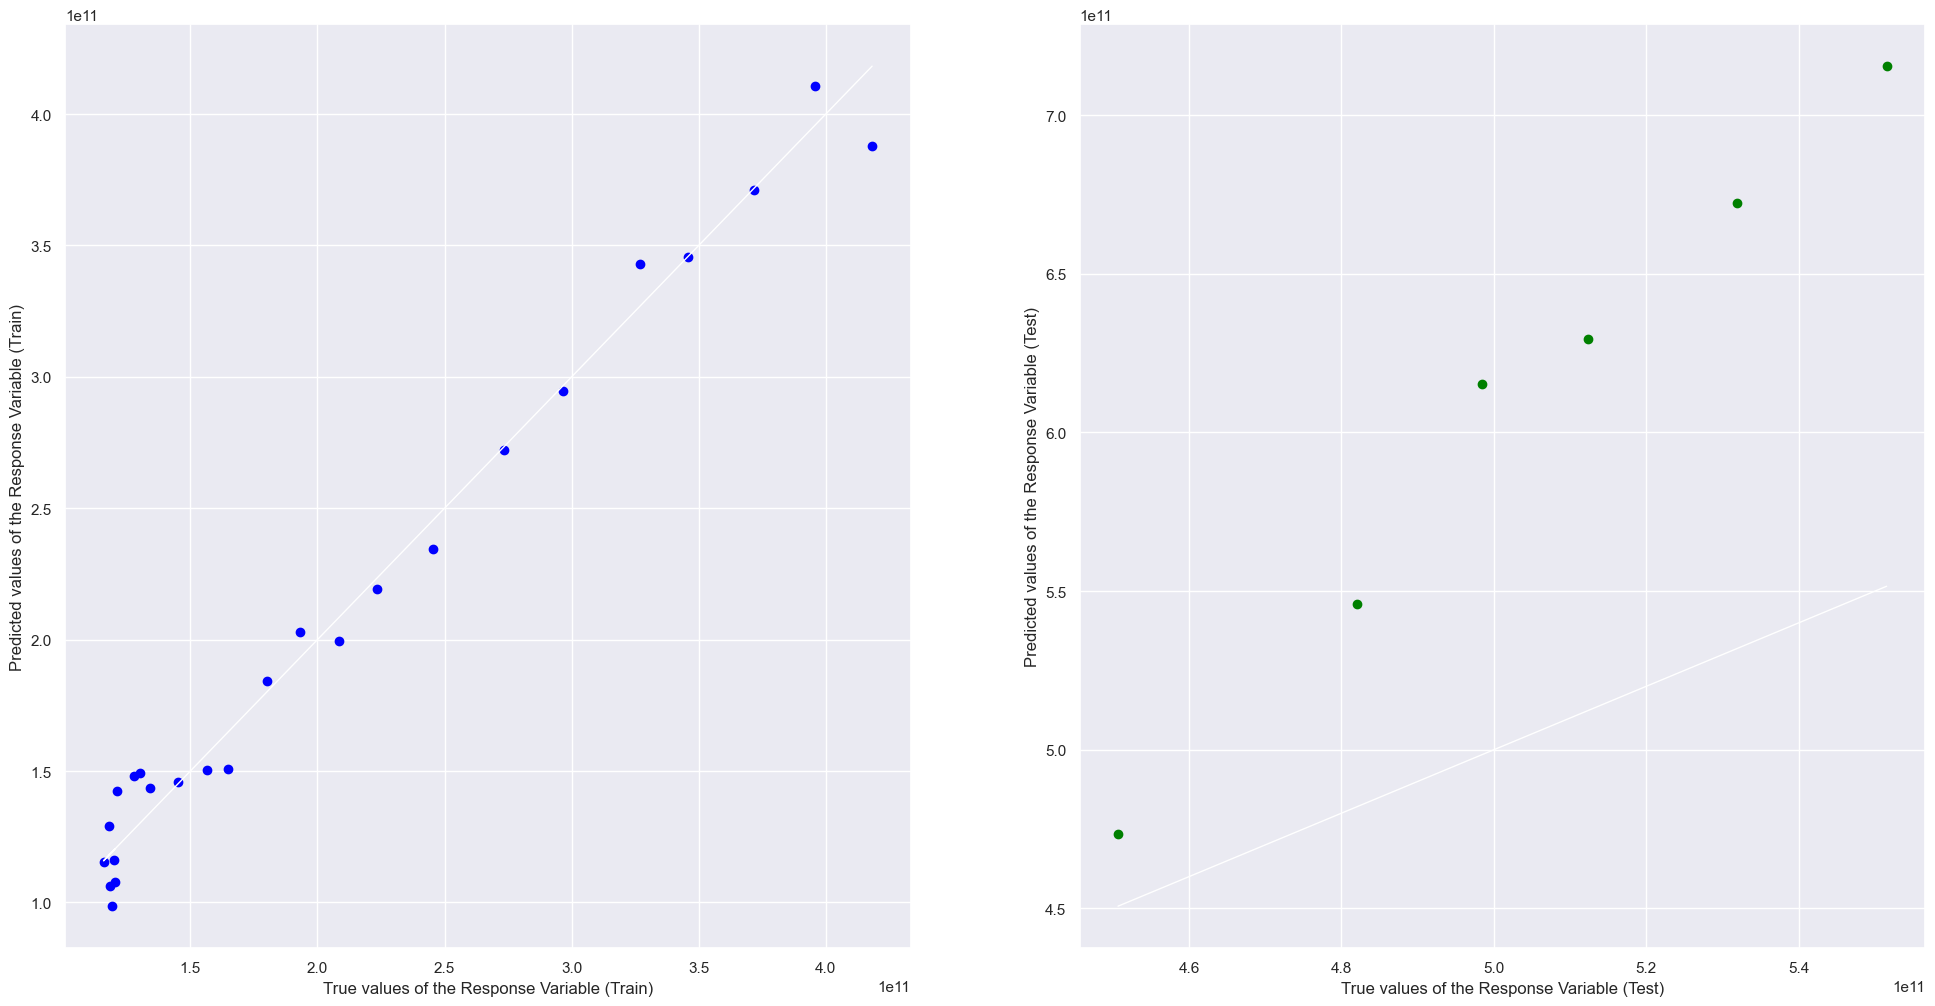

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9823426069668266
Mean Squared Error (MSE) 	: 1.667019198502957e+20

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: -11.174380992238365
Mean Squared Error (MSE) 	: 1.3100587723767857e+22



In [7]:
# 5 Predictors


Algeria = pd.DataFrame(d1[d1["country"] == "Algeria"])

# Just the column names now — plain lists, not DataFrames
feature_cols = ["population","primary_energy_consumption","electricity_generation","fossil_share_energy","energy_per_capita"]
target_col = "gdp"

train_df = Algeria[Algeria["year"] < 2010]
test_df  = Algeria[(Algeria["year"] >= 2010) & (Algeria["year"] <= 2015)]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

print(X_train.shape, X_test.shape)

# Linear Regression using Train Data
linreg = LinearRegression()         # create the linear regression object
linreg.fit(X_train, y_train)        # train the linear regression model

# Coefficients of the Linear Regression line
print('Intercept of Regression \t: b = ', linreg.intercept_)
print('Coefficients of Regression \t: a = ', linreg.coef_)
print()

# Print the Coefficients against Predictors
print(pd.DataFrame(list(zip(X_train.columns, linreg.coef_)), columns = ["Predictors", "Coefficients"]))
print()

# Predict Response corresponding to Predictors
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)

# Plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, y_train_pred, color = "blue")
axes[0].plot(y_train, y_train, 'w-', linewidth = 1)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, y_test_pred, color = "green")
axes[1].plot(y_test, y_test, 'w-', linewidth = 1)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
plt.show()

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_train, y_train))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_train, y_train_pred))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_test, y_test))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_test, y_test_pred))
print()

(25, 1) (6, 1)
Intercept of Regression 	: b =  -61966453838.812744
Coefficients of Regression 	: a =  [1.13170079e+10]

               Predictors  Coefficients
0  electricity_generation  1.131701e+10



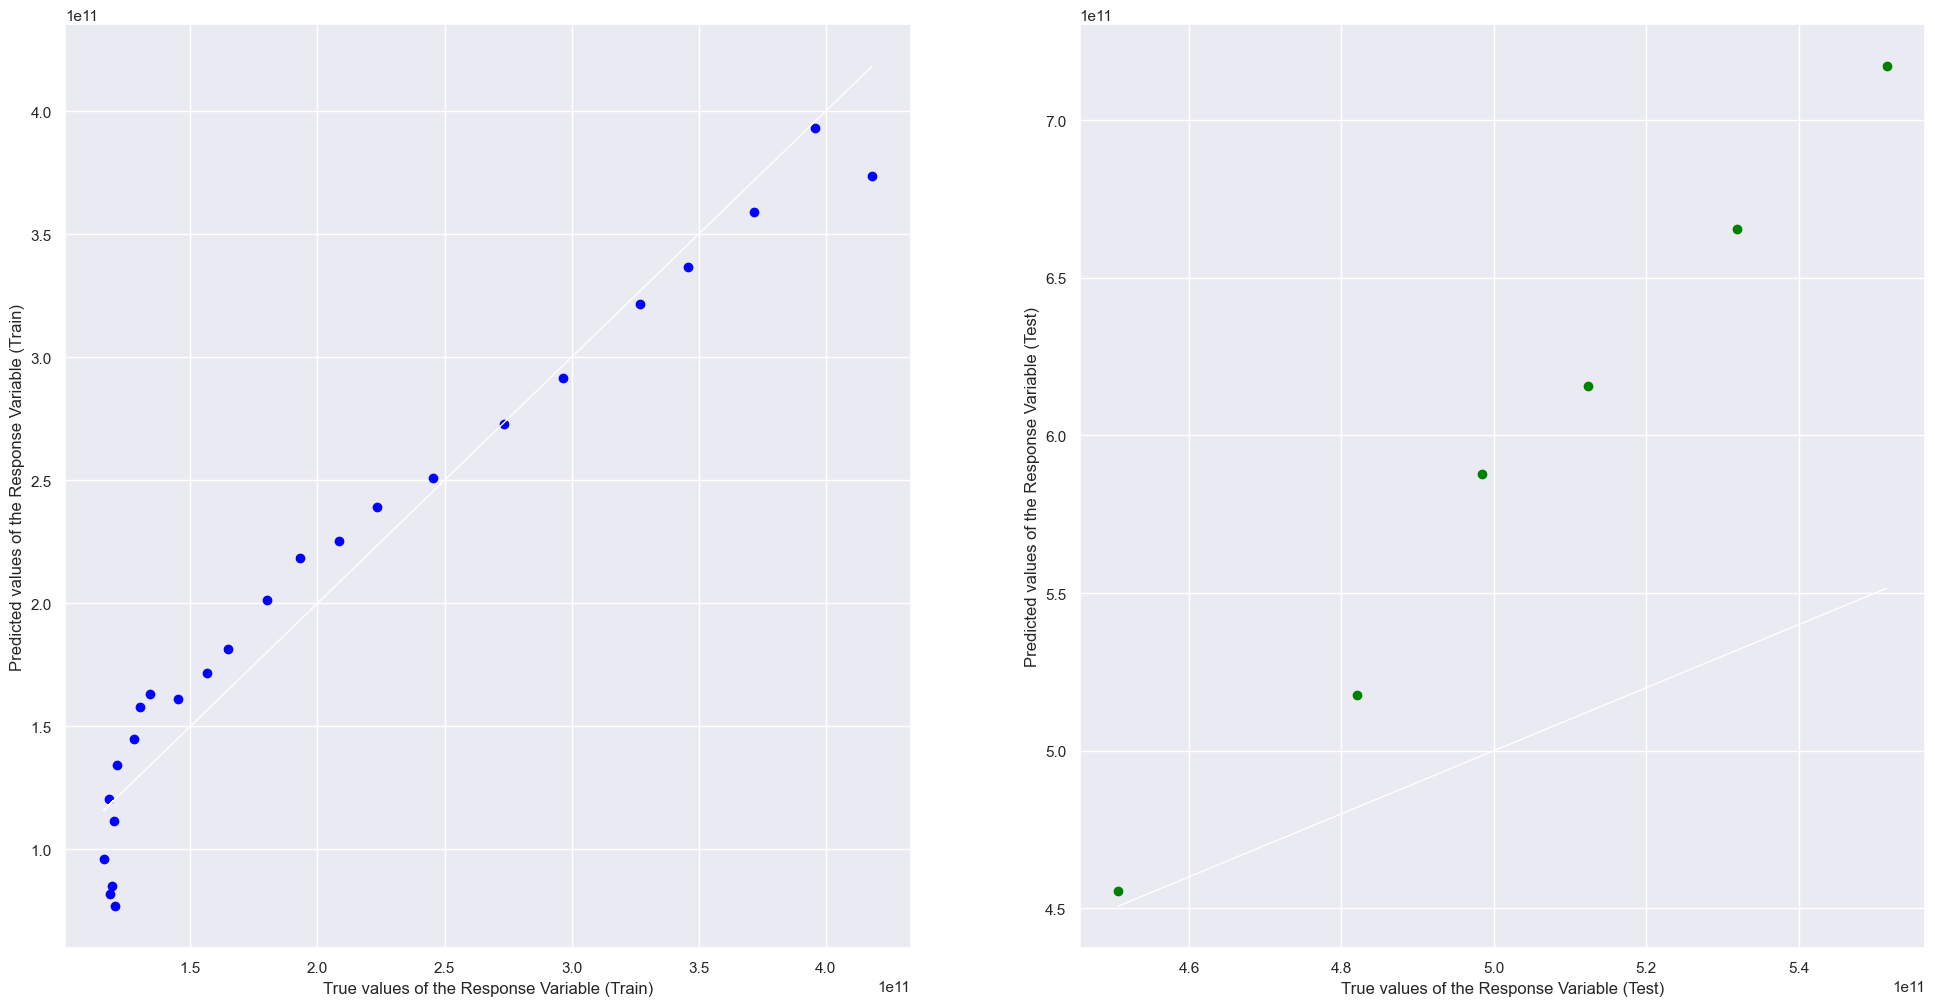

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9509139478841595
Mean Squared Error (MSE) 	: 4.6341717093849484e+20

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: -9.098311351944322
Mean Squared Error (MSE) 	: 1.0866574145528198e+22



In [9]:
# 1 Predictor


Algeria = pd.DataFrame(d1[d1["country"] == "Algeria"])

# Just the column names now — plain lists, not DataFrames
feature_cols = ["electricity_generation"]
target_col = "gdp"

train_df = Algeria[Algeria["year"] < 2010]
test_df  = Algeria[(Algeria["year"] >= 2010) & (Algeria["year"] <= 2015)]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

print(X_train.shape, X_test.shape)

# Linear Regression using Train Data
linreg = LinearRegression()         # create the linear regression object
linreg.fit(X_train, y_train)        # train the linear regression model

# Coefficients of the Linear Regression line
print('Intercept of Regression \t: b = ', linreg.intercept_)
print('Coefficients of Regression \t: a = ', linreg.coef_)
print()

# Print the Coefficients against Predictors
print(pd.DataFrame(list(zip(X_train.columns, linreg.coef_)), columns = ["Predictors", "Coefficients"]))
print()

# Predict Response corresponding to Predictors
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)

# Plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, y_train_pred, color = "blue")
axes[0].plot(y_train, y_train, 'w-', linewidth = 1)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, y_test_pred, color = "green")
axes[1].plot(y_test, y_test, 'w-', linewidth = 1)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
plt.show()

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_train, y_train))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_train, y_train_pred))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_test, y_test))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_test, y_test_pred))
print()

(25, 3) (6, 3)
Intercept of Regression 	: b =  174034939680.7365
Coefficients of Regression 	: a =  [-1.47790443e+04  1.70248789e+08  1.71596138e+10]

                   Predictors  Coefficients
0                  population -1.477904e+04
1  primary_energy_consumption  1.702488e+08
2      electricity_generation  1.715961e+10



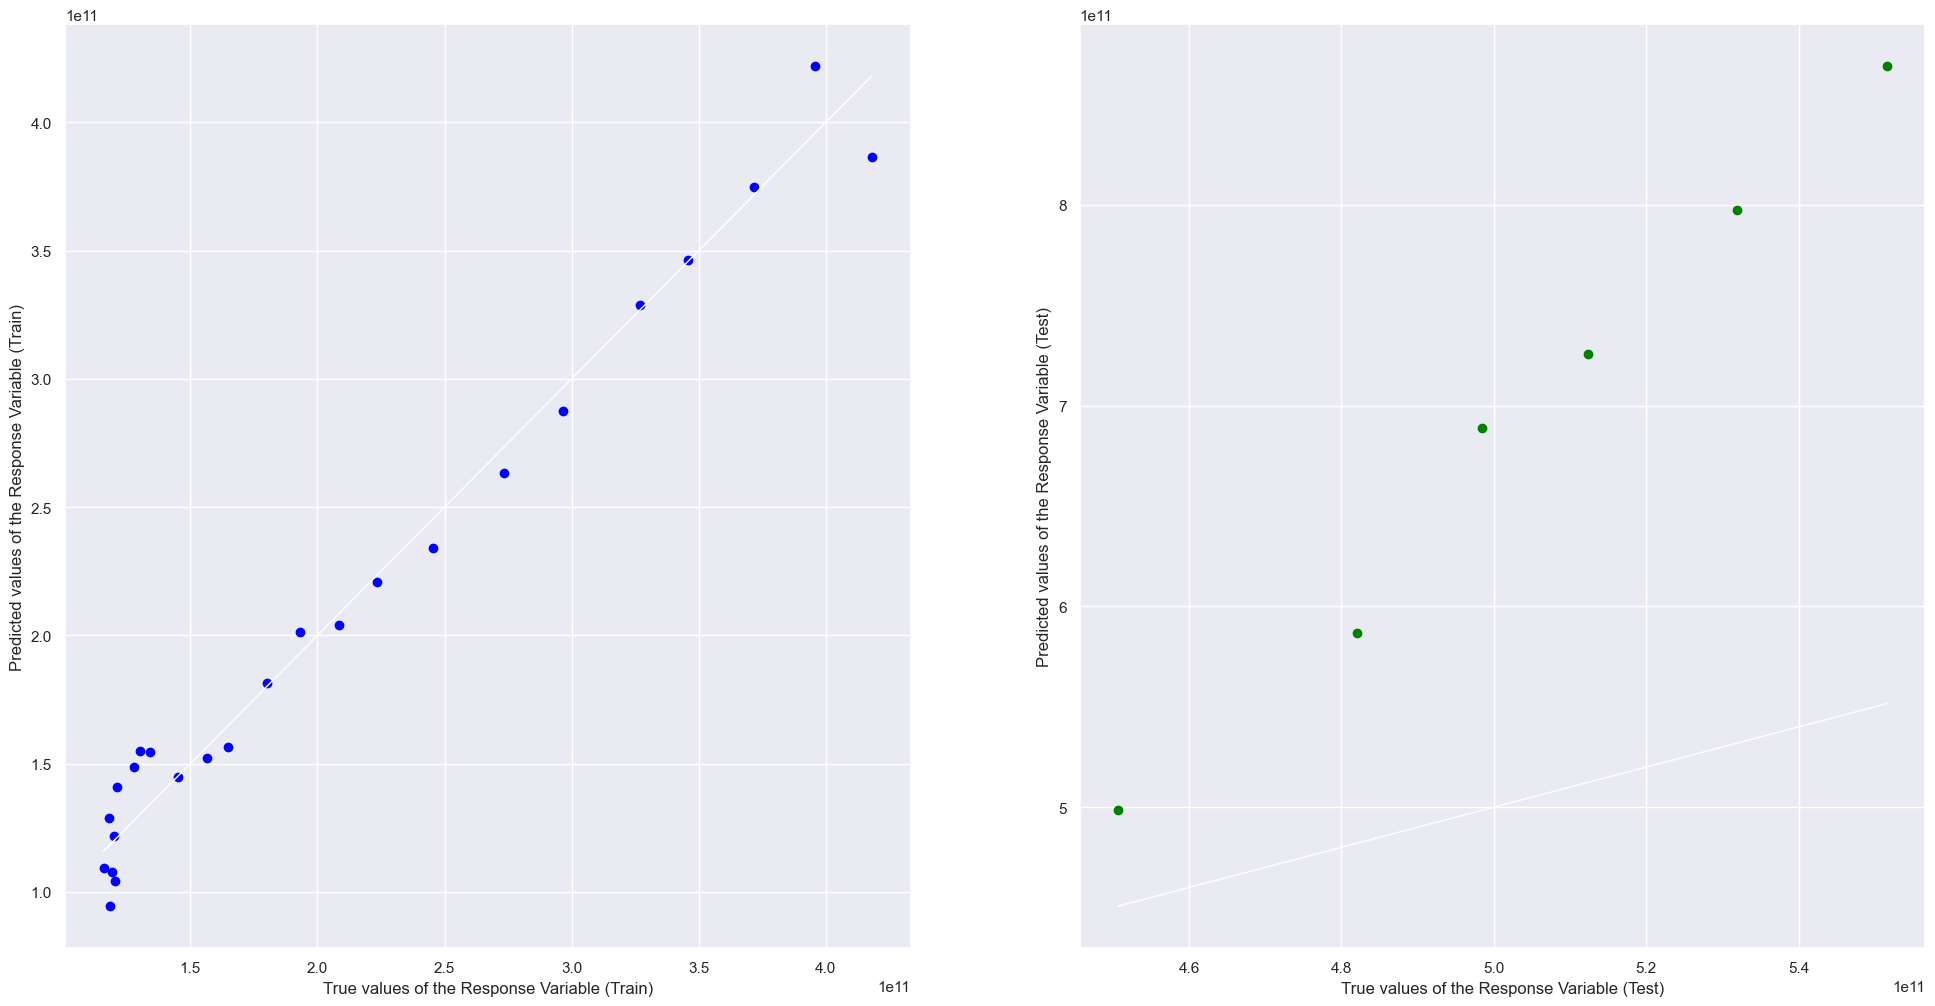

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9780969163993145
Mean Squared Error (MSE) 	: 2.0678511714702387e+20

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: -40.22252080014991
Mean Squared Error (MSE) 	: 4.435866187213171e+22



In [10]:
# 3 Predictors


Algeria = pd.DataFrame(d1[d1["country"] == "Algeria"])

# Just the column names now — plain lists, not DataFrames
feature_cols = ["population","primary_energy_consumption","electricity_generation"]
target_col = "gdp"

train_df = Algeria[Algeria["year"] < 2010]
test_df  = Algeria[(Algeria["year"] >= 2010) & (Algeria["year"] <= 2015)]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

print(X_train.shape, X_test.shape)

# Linear Regression using Train Data
linreg = LinearRegression()         # create the linear regression object
linreg.fit(X_train, y_train)        # train the linear regression model

# Coefficients of the Linear Regression line
print('Intercept of Regression \t: b = ', linreg.intercept_)
print('Coefficients of Regression \t: a = ', linreg.coef_)
print()

# Print the Coefficients against Predictors
print(pd.DataFrame(list(zip(X_train.columns, linreg.coef_)), columns = ["Predictors", "Coefficients"]))
print()

# Predict Response corresponding to Predictors
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)

# Plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, y_train_pred, color = "blue")
axes[0].plot(y_train, y_train, 'w-', linewidth = 1)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, y_test_pred, color = "green")
axes[1].plot(y_test, y_test, 'w-', linewidth = 1)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
plt.show()

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_train, y_train))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_train, y_train_pred))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_test, y_test))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_test, y_test_pred))
print()

(38, 15)
(25, 2) (6, 2)
Intercept of Regression 	: b =  -519294569210.37067
Coefficients of Regression 	: a =  [1.15266883e+04 1.19754815e+09]

                   Predictors  Coefficients
0                  population  1.152669e+04
1  primary_energy_consumption  1.197548e+09



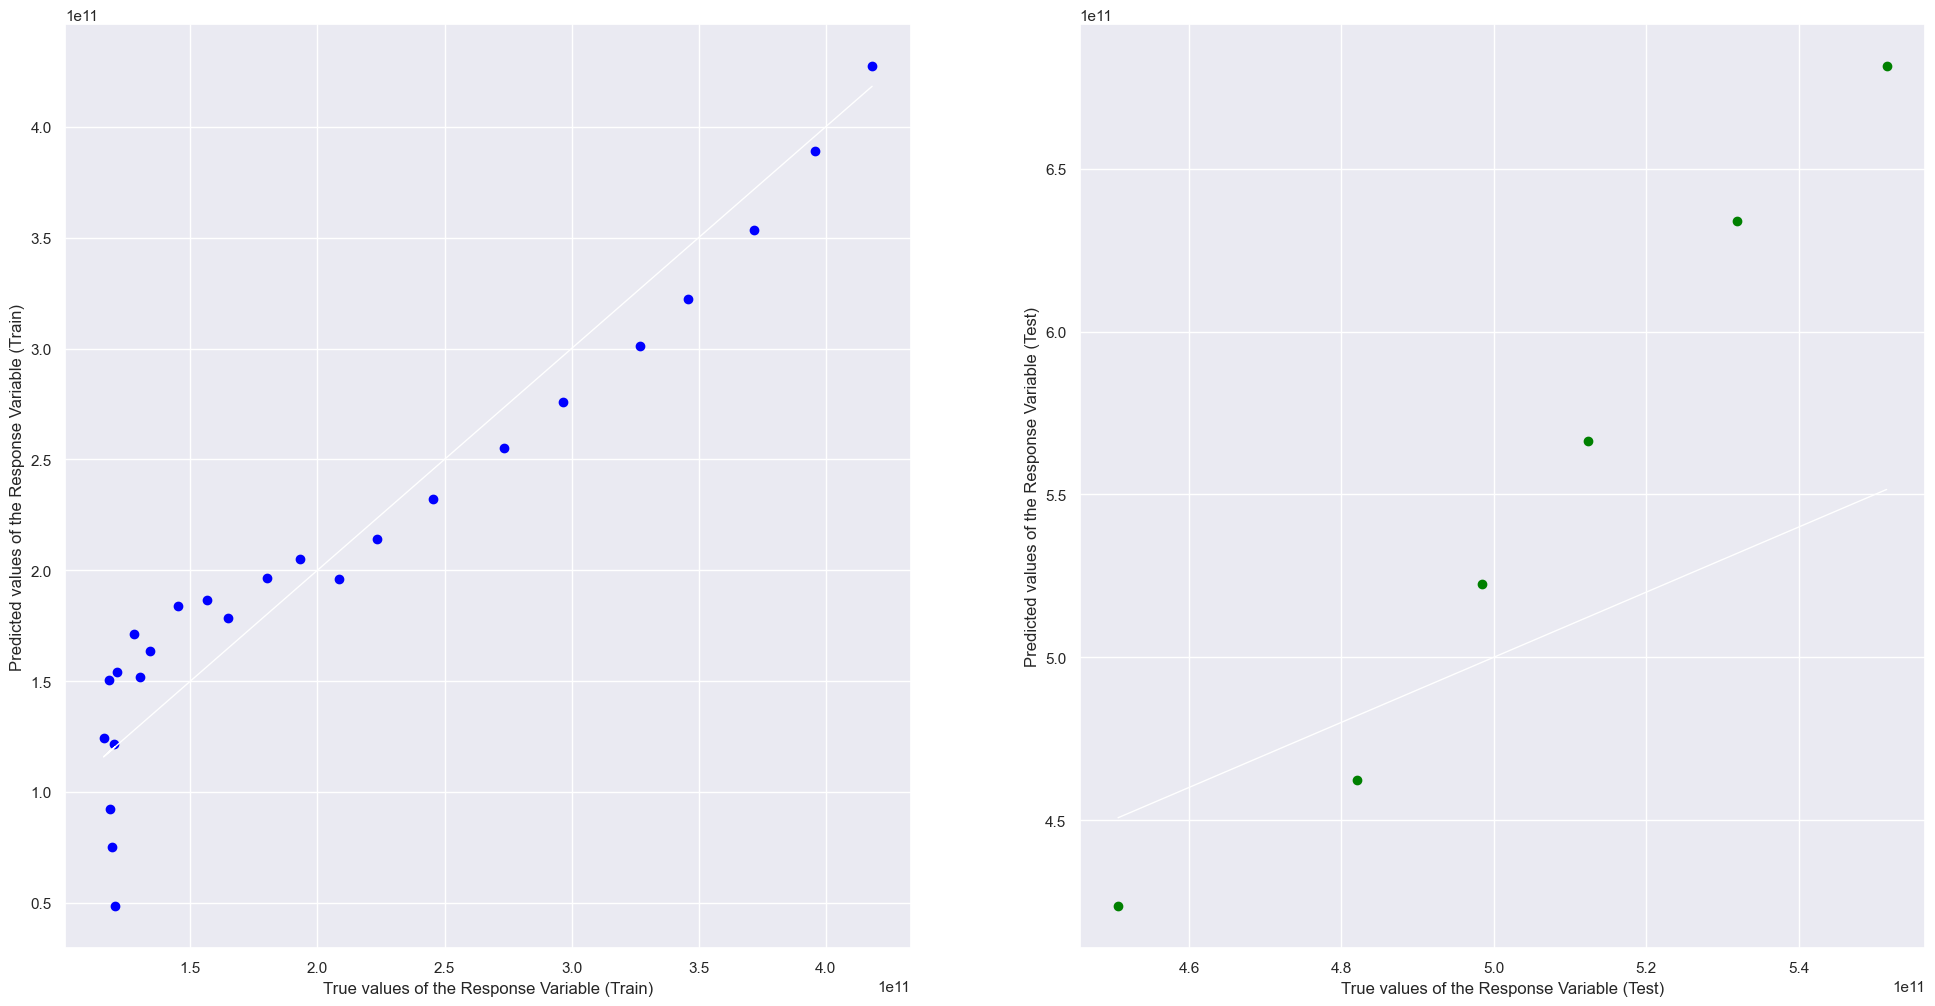

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9192618314684029
Mean Squared Error (MSE) 	: 7.622420633741264e+20

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: -3.9498670151867064
Mean Squared Error (MSE) 	: 5.326444695198904e+21


In [12]:
# 11 Predictors


# Import essential models and functions from sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()

# ---- Step 1: Build a clean Algeria subset from the full dataset ----
all_candidate_cols = [
    "country", "year", "iso_code", "gdp",
    "population", "electricity_generation", "primary_energy_consumption", 
    "fossil_share_energy", "energy_per_capita",
    "renewables_share_energy", "coal_share_energy", "oil_share_energy", "gas_share_energy",
    "low_carbon_share_energy", "renewables_share_elec"
]

Algeria = d[d["country"] == "Algeria"][all_candidate_cols]
Algeria = Algeria.dropna()   # safe here since we already confirmed full coverage for these columns

print(Algeria.shape)   # sanity check -- expect around 31 rows

# ---- Step 2: Choose your final feature columns (based on your correlation analysis) ----
feature_cols = ["population", "primary_energy_consumption"]   # <-- edit this list as needed
target_col = "gdp"

# ---- Step 3: Temporal train/test split ----
train_df = Algeria[Algeria["year"] < 2010]
test_df  = Algeria[(Algeria["year"] >= 2010) & (Algeria["year"] <= 2015)]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

print(X_train.shape, X_test.shape)

# ---- Step 4: Fit Linear Regression ----
linreg = LinearRegression()
linreg.fit(X_train, y_train)

print('Intercept of Regression \t: b = ', linreg.intercept_)
print('Coefficients of Regression \t: a = ', linreg.coef_)
print()
print(pd.DataFrame(list(zip(X_train.columns, linreg.coef_)), columns=["Predictors", "Coefficients"]))
print()

# ---- Step 5: Predict ----
y_train_pred = linreg.predict(X_train)
y_test_pred  = linreg.predict(X_test)

# ---- Step 6: Plot predictions vs true values ----
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, y_train_pred, color="blue")
axes[0].plot(y_train, y_train, 'w-', linewidth=1)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")

axes[1].scatter(y_test, y_test_pred, color="green")
axes[1].plot(y_test, y_test, 'w-', linewidth=1)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
plt.show()

# ---- Step 7: Goodness of fit ----
print("Goodness of Fit of Model \tTrain Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_train, y_train))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_train, y_train_pred))
print()
print("Goodness of Fit of Model \tTest Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_test, y_test))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_test, y_test_pred))